In [66]:
from textwrap import wrap
from sklearn.feature_selection import chi2
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

In [ ]:
df = pd.read_csv('olist_cleaned.csv')

In [ ]:
def format_labels(labels, short=False):
    """Replaces _ with space and sets maximum char length"""
    result = []
    for label in labels:
        spaced = " ".join(label.split("_"))
        if len(spaced)>20 and short == True:
            result.append(spaced[:18]+"...")
        else:
            result.append("\n".join(wrap(spaced,20)))
    return result

# Graphs

## Target Variable: Review Score

In [ ]:
ax = sns.countplot(data=df, x='review_score', order=sorted(df["review_score"].unique()), hue="review_score", legend=None)

values = df['review_score'].value_counts().sort_index()
percentages = (values/values.sum())*100
for patch, count, percentage in zip(
    [patch for patch in ax.patches if patch.get_height() > 0],
    values,
    percentages
):
    ax.annotate(
        f"{count:,} ({percentage:.1f}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 2),
        textcoords="offset points",
        fontsize=8
    )

order = sorted(df["review_score"].unique())

ax.set_xticks(ticks=range(len(order)), labels=[1,2,3,4,5])
ax.set_xticklabels([str(int(score)) for score in order])

ax.set_title('Review score distribution')
ax.set_xlabel('Review Score')
ax.set_ylabel('Count')
plt.show()

In [ ]:
ax = sns.countplot(data=df, x='score_category', order=sorted(df["score_category"].unique()), hue="score_category", palette='ocean', legend=None)

values = df['score_category'].value_counts().sort_index()
percentages = (values/values.sum())*100
for patch, count, percentage in zip(
    [patch for patch in ax.patches if patch.get_height() > 0],
    values,
    percentages
):
    ax.annotate(
        f"{count:,} ({percentage:.1f}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 1),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title('Review score category distribution')
ax.set_xlabel('Review Score')
ax.set_ylabel('Count')
plt.show()

## Numerical Features

In [ ]:
# Correlation matrix of select numerical features
df_reduced = df[['review_score','price','freight_value','product_photos_qty',
                       'payment_sequential','payment_installments_total',
                       'carrier_offset', 'customer_offset', 
                       'delivered_carrier_days', 'delivered_customer_days',
                       'approval_duration', 'customer_eta_days']]
corr = df_reduced.corr()
label = format_labels(list(df_reduced.columns))

sns.set_theme(style="white")
cmap = sns.diverging_palette(230, 20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, cmap=cmap, annot=True, fmt=".2f",mask=mask, square = True, annot_kws={'size': 8}, xticklabels=label, yticklabels=label)
plt.tick_params(axis='both', labelsize=10)
plt.yticks(va='center', rotation_mode='anchor')
plt.xticks(ha='right', rotation_mode='xtick')
plt.title('Correlation Matrix of Review Score, Price, Freight Value and new features')
plt.show()

In [ ]:
# Correlation matrix of all numerical features
corr = df.select_dtypes(include=[int, float, np.number]).corr()
label = format_labels(list(df.select_dtypes(include=[int, float, np.number]).columns),short=True)

sns.set_theme(style="white")
cmap = sns.diverging_palette(230, 20, as_cmap=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap=cmap, annot=True, fmt=".2f", square = True, annot_kws={'size': 7}, xticklabels=label, yticklabels=label)
plt.tick_params(axis='both', labelsize=7)
plt.yticks(va='center', rotation_mode='anchor', rotation=45)
plt.xticks(ha='left', rotation_mode='xtick', rotation=45)
plt.title('Heatmap of all numerical features')
plt.show()

### Numerical-Categorical

In [83]:
categorical_cols = [
    "delivered_carrier",
    "delivered_customer",
    "seller_state",
    "customer_state",
    "order_status",
    "payment_type_all",
    "product_category_name_english",
]

mean_score_ranking = (
    df.groupby(categorical_cols, dropna=False)["review_score"]
      .mean()
)

print(mean_score_ranking)

delivered_carrier  delivered_customer  seller_state  customer_state  order_status  payment_type_all  product_category_name_english
early              early               AM            MG              delivered     credit_card       telephony                        1.0
                                       BA            AL              delivered     credit_card       computers                        4.5
                                                                                                     computers_accessories            4.5
                                                                                                     health_beauty                    4.0
                                                                                                     telephony                        5.0
                                                                                                                                     ... 
on_time            on_time             SP

In [84]:
mean_score_summary = []

for col in categorical_cols:
    grouped = (
        df.groupby(col, dropna=False)["review_score"]
        .agg(["mean", "count"])
        .reset_index()
        .rename(columns={
            col: "category",
            "mean": "mean_score"
        })
    )
    grouped["feature"] = col
    mean_score_summary.append(grouped)

mean_score_summary = pd.concat(mean_score_summary, ignore_index=True)

mean_score_summary.sort_values(
    "mean_score",
    ascending=False
).head(20)

,category,mean_score,count,feature
81,cds_dvds_musicals,4.642857,14,product_category_name_english
19,PA,4.500000,8,seller_state
99,fashion_childrens_clothes,4.500000,8,product_category_name_english
17,MS,4.469388,49,seller_state
78,books_general_interest,4.446266,549,product_category_name_english
92,costruction_tools_tools,4.444444,99,product_category_name_english
105,flowers,4.419355,31,product_category_name_english
79,books_imported,4.400000,60,product_category_name_english
80,books_technical,4.361217,263,product_category_name_english
123,luggage_accessories,4.313996,1086,product_category_name_english


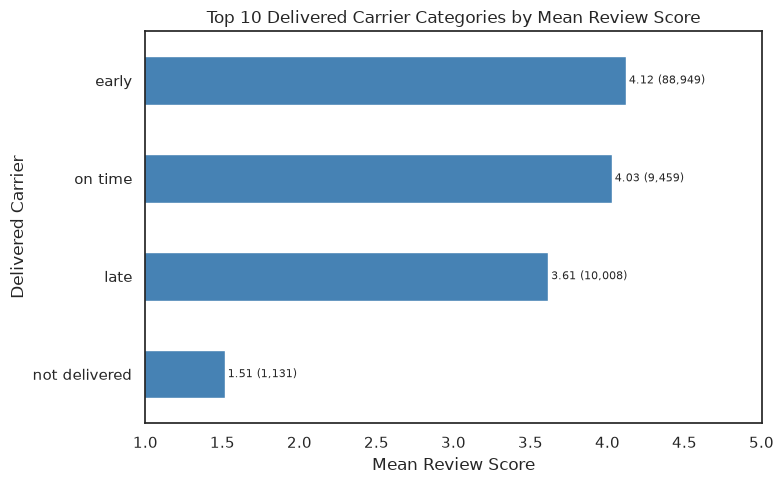

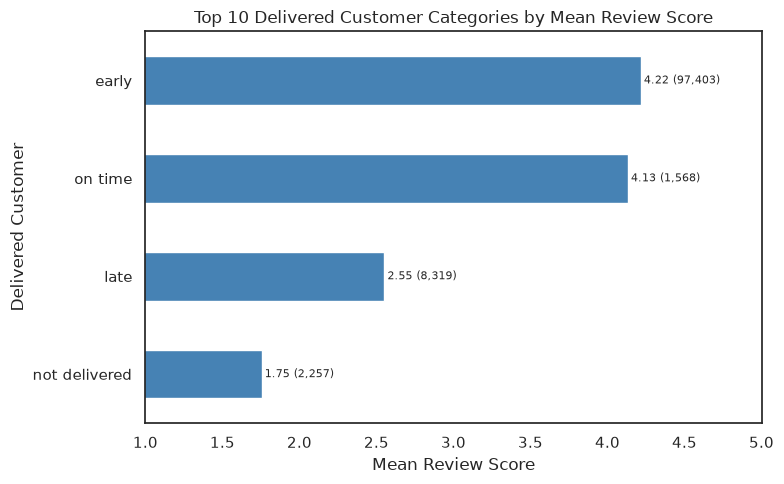

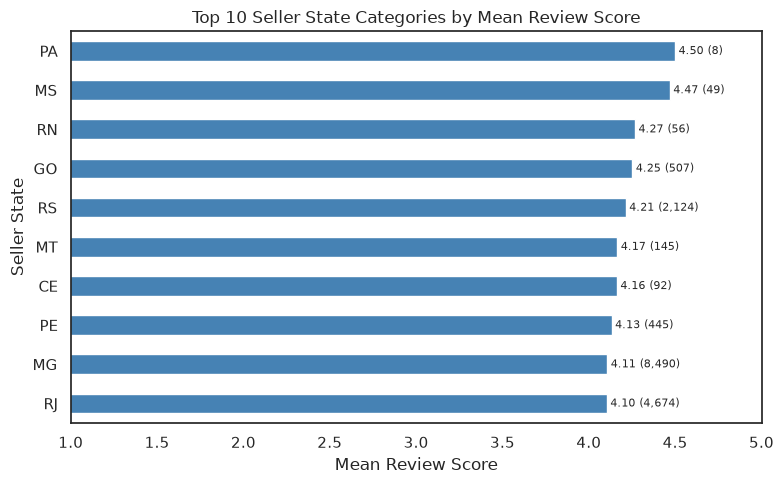

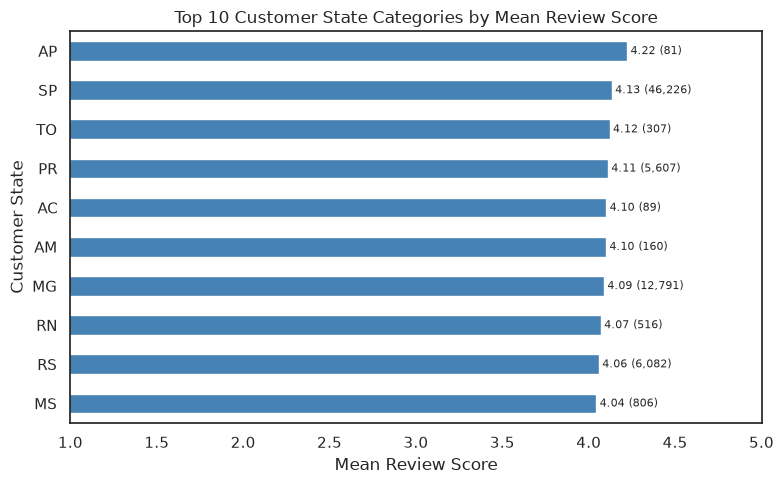

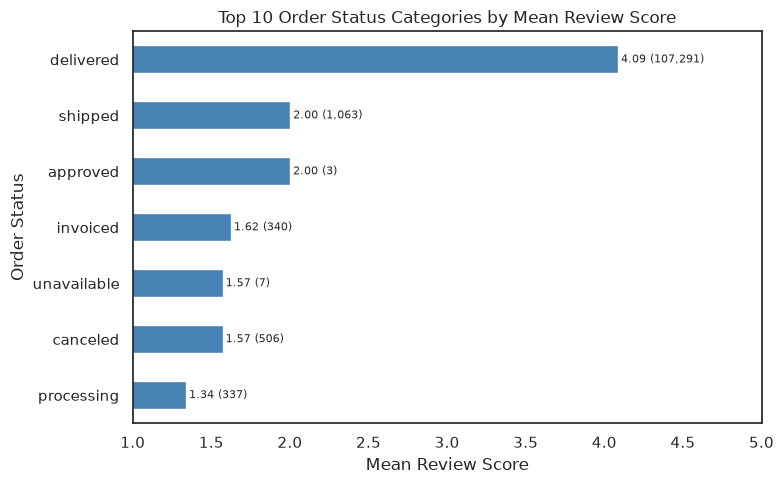

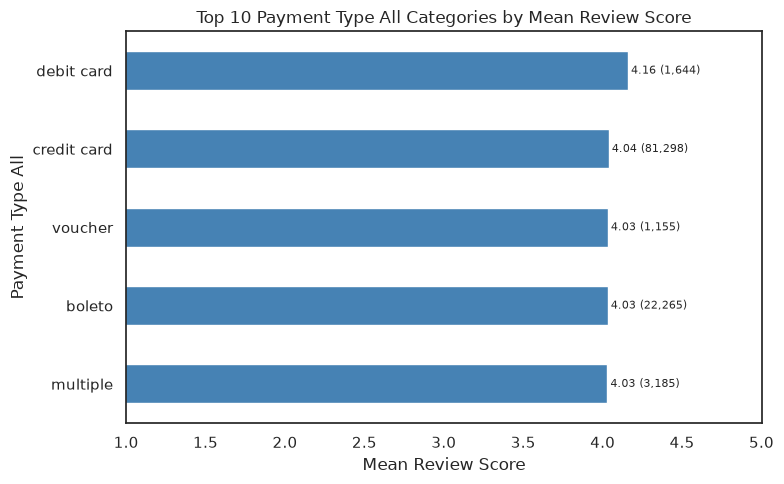

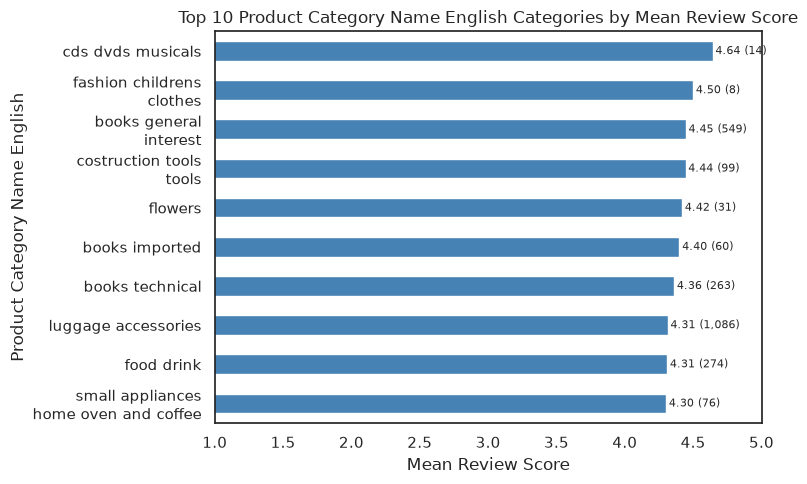

In [86]:
for col in categorical_cols:
    mean_score_ranking = (
        df.groupby(col, dropna=False)["review_score"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "mean_score"})
        .sort_values("mean_score", ascending=False)
        .head(10)
        .sort_values("mean_score")
    )

    ax = mean_score_ranking["mean_score"].plot(
        kind="barh",
        figsize=(8, 5),
        color="steelblue"
    )

    ax.set_title(
        f"Top 10 {col.replace('_', ' ').title()} Categories "
        "by Mean Review Score"
    )
    ax.set_xlabel("Mean Review Score")
    ax.set_ylabel(col.replace("_", " ").title())
    ax.set_yticklabels(format_labels(mean_score_ranking.index.tolist()))
    ax.set_xlim(1, 5)

    for position, (score, count) in enumerate(
        zip(mean_score_ranking["mean_score"], mean_score_ranking["count"])
    ):
        ax.text(
            score + 0.02,
            position,
            f"{score:.2f} ({count:,})",
            va="center",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

In [ ]:
sns.boxplot(data=df, x='customer_offset', y='review_score', orient='y',hue='review_score',legend=None)
plt.title('Review score distribution')
plt.ylabel('Review Score')
plt.xlabel('Offset days from customer ETA')
plt.show()

In [ ]:
payment_type_score = df.groupby('payment_type_all')['review_score'].mean().nlargest(10)
labels = list(payment_type_score.index)

sns.barplot(data=payment_type_score, orient='h')
plt.title('Payment Methods by Average Review Score')
plt.xlabel('Average Review Score')
plt.ylabel('Payment Types')
plt.yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')
plt.show()

labels=df['payment_type_all'].unique().dropna()
sns.countplot(data=df, x='payment_type_all',hue='payment_type_all',legend=False,palette='rocket')
plt.title('Payment type distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(labels, format_labels(labels))
plt.show()

sns.countplot(data=df, x='payment_type_all',hue='review_score')
plt.title('Payment type distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(labels, format_labels(labels))
plt.show()

In [ ]:
cat_score_big = df.groupby('product_category_name_english')['review_score'].mean().nlargest(10)
labels = list(cat_score_big.index)

fig, axes = plt.subplots(2,1,figsize=(7,7),sharex=True)

sns.barplot(data=cat_score_big,orient='h', palette='ocean',ax=axes[0])
axes[0].set_title('Top 10 Categories by Average Review Scores')
axes[0].set_xlabel('Average Review Scores')
axes[0].set_ylabel('Product Categories')
axes[0].set_yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')

cat_score_small = df.groupby('product_category_name_english')['review_score'].mean().nsmallest(10)
labels = list(cat_score_small.index)

sns.barplot(data=cat_score_small,orient='h', palette='ocean_r',ax=axes[1])
axes[1].set_title('Bottom 10 Categories by Average Review Scores')
axes[1].set_xlabel('Average Review Scores')
axes[1].set_ylabel('Product Categories')
axes[1].set_yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')

plt.tight_layout()
plt.show()

In [ ]:
top10_cust_state_score = df.groupby('customer_state')['review_score'].mean().nlargest(10)
bot10_cust_state_score = df.groupby('customer_state')['review_score'].mean().nsmallest(10)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

sns.barplot(data=top10_cust_state_score,orient='h',ax=axes[0])
# axes[0].set_title('Top 10 States by Average Review Scores (Customer)')
# axes[0].set_xlabel('Review Score')
# axes[0].set_ylabel('Customer State')
sns.barplot(data=bot10_cust_state_score,orient='h',ax=axes[0])
# axes[0].set_title('Top 10 States by Average Review Scores (Customer)')
# axes[0].set_xlabel('Review Score')
# axes[0].set_ylabel('Customer State')

top10_seller_state_score = df.groupby('seller_state')['review_score'].mean().nlargest(10)
bot10_seller_state_score = df.groupby('seller_state')['review_score'].mean().nsmallest(10)

sns.barplot(data=top10_seller_state_score,orient='h',ax=axes[1])
# axes[1].set_title('Top 10 States by Average Review Scores (Seller)')
# axes[1].set_xlabel('Review Score')
# axes[1].set_ylabel('Seller State')
sns.barplot(data=bot10_seller_state_score,orient='h',ax=axes[1])
# axes[1].set_title('Top 10 States by Average Review Scores (Seller)')
# axes[1].set_xlabel('Review Score')
# axes[1].set_ylabel('Seller State')

plt.tight_layout()
plt.show()

In [ ]:
order_status_score = df.groupby('order_status')['review_score'].mean().nlargest(10)
labels = list(order_status_score.index)

sns.barplot(data=order_status_score,orient='h', palette='viridis')
plt.title('Distribution of Order Status by Average Review Scores')
plt.xlabel('Average Review Score')
plt.ylabel('Order Status')
plt.yticks(labels, format_labels(labels), va='center', rotation_mode='anchor')
plt.show()

labels = df['order_status'].unique().dropna()
sns.countplot(data=df, x='order_status',hue='order_status',legend=False,palette='rocket')
plt.title('Order status distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(labels, format_labels(labels))
plt.show()

sns.countplot(data=df, x='order_status',hue='review_score')
plt.title('Order status distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(labels, format_labels(labels))
plt.show()

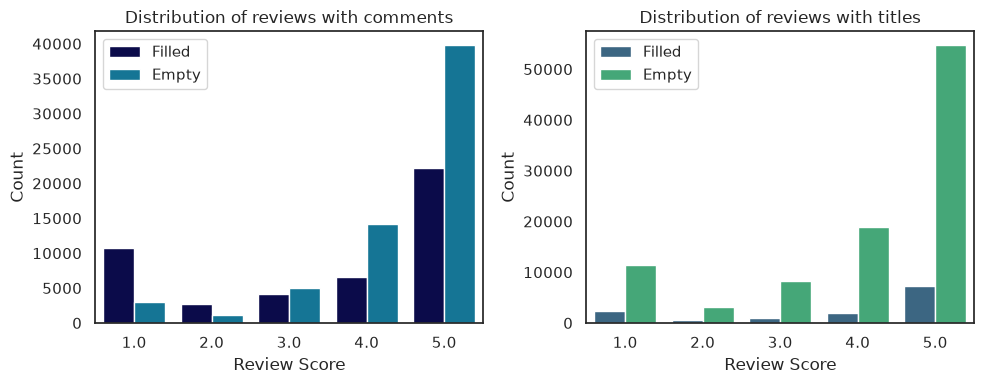

In [51]:
empty_reviews = pd.concat(
    [df['review_score'],
     df['review_comment_message'].isna().rename("empty_comment"),
     df['review_comment_title'].isna().rename("empty_title")],
     axis=1
)
label = ['Filled', 'Empty']

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

sns.countplot(data=empty_reviews,x='review_score', hue='empty_comment', palette='ocean',ax=axes[0])
axes[0].legend(labels = label)
axes[0].set_title('Distribution of reviews with comments')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Count')

sns.countplot(data=empty_reviews,x='review_score', hue='empty_title', palette='viridis',ax=axes[1])
axes[1].legend(labels=label)
axes[1].set_title('Distribution of reviews with titles')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Categorical Features

* Rank using mean of review score of each categorical feature
* Numerical - Categorical: ANOVA F-test
* Categorical - Categorical: Chi-square
* Use SelectKBest(review_score = , k = 5) if using mutual information (num/cat - cat). this is based off probability

In [37]:
y = df['score_category']
X = df.select_dtypes(include=[str]).drop(columns=[
    'score_category',
    'product_category_name',
    'product_category_name_english',
    'review_comment_title',
    'review_comment_message'])
print(X.columns)

Index(['order_status', 'payment_type_all', 'seller_city', 'seller_state',
       'customer_city', 'customer_state', 'delivered_carrier',
       'delivered_customer'],
      dtype='str')


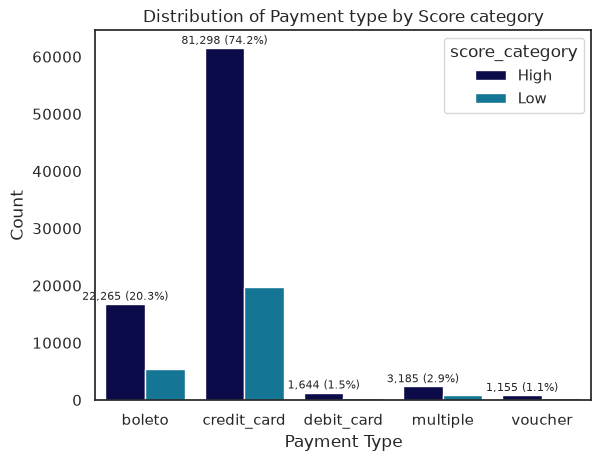

In [44]:
ax = sns.countplot(data=df, x='payment_type_all', order=sorted(df["payment_type_all"].unique()), hue="score_category", palette='ocean')

values = df['payment_type_all'].value_counts().sort_index()
percentages = (values/values.sum())*100
for patch, count, percentage in zip(
    [patch for patch in ax.patches if patch.get_height() > 0],
    values,
    percentages
):
    ax.annotate(
        f"{count:,} ({percentage:.1f}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 1),
        textcoords="offset points",
        fontsize=8
    )

ax.set_title('Distribution of Payment type by Score category')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Count')
plt.show()

In [65]:
# categorical_cols = [
#     "delivered_carrier",
#     "delivered_customer",
#     "seller_state",
#     "customer_state",
#     "order_status",
#     "payment_type_all",
#     "product_category_name_english",
# ]

# for col in categorical_cols:
#     top_categories = df[col].value_counts().head(10).index

#     plt.figure(figsize=(10, 5))
#     sns.countplot(
#         data=df[df[col].isin(top_categories)],
#         x=col,
#         hue="score_category",
#         order=top_categories,
#         palette="ocean"
#     )

#     plt.title(f"{col.replace('_', ' ').title()} by Score Category")
#     plt.xlabel(col.replace("_", " ").title())
#     plt.ylabel("Count")
#     plt.xticks(rotation=45, ha="right")
#     plt.legend(title="Score Category")
#     plt.tight_layout()
#     plt.show()

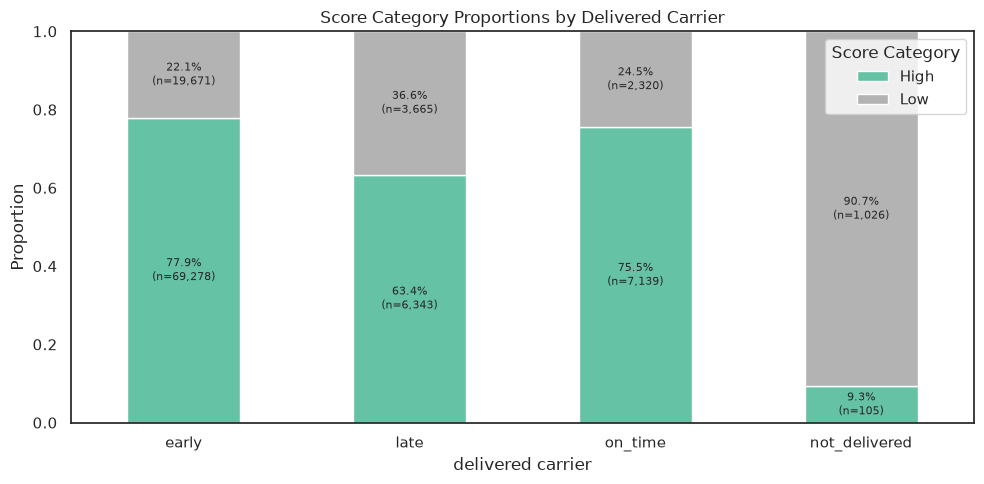

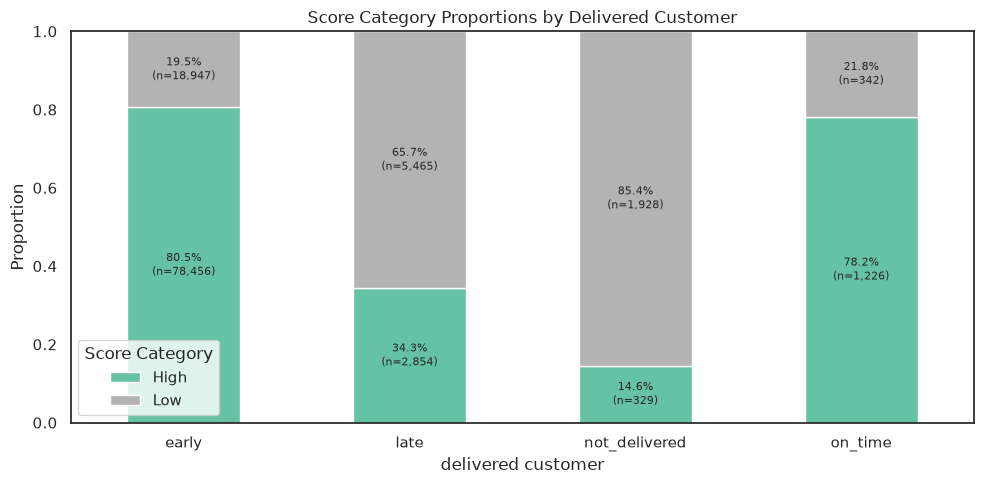

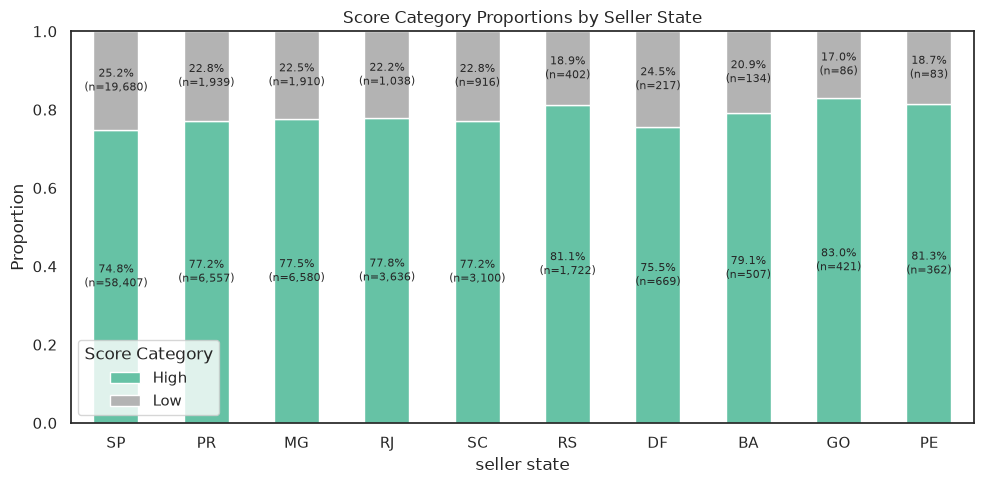

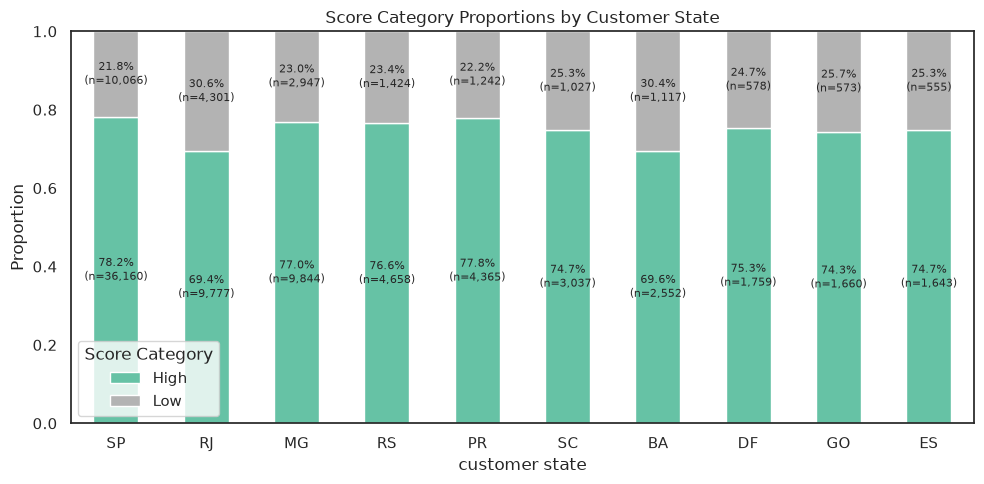

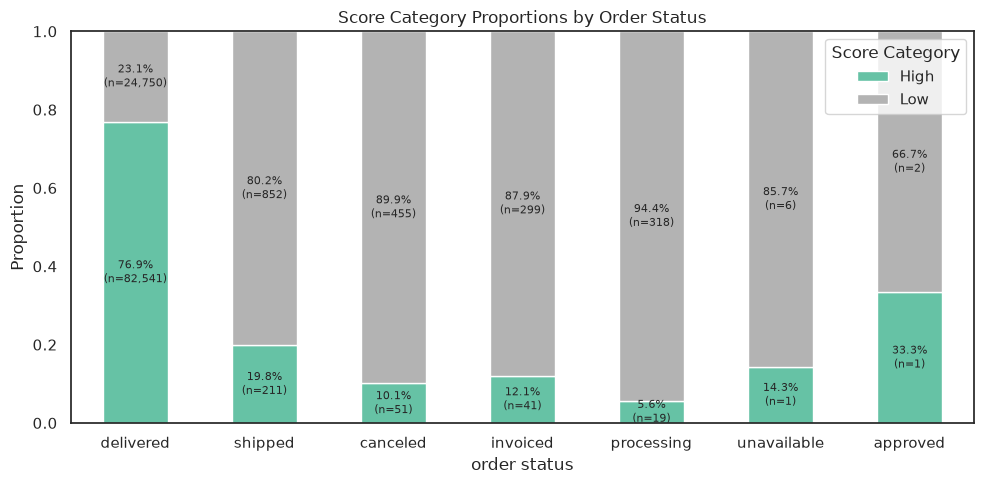

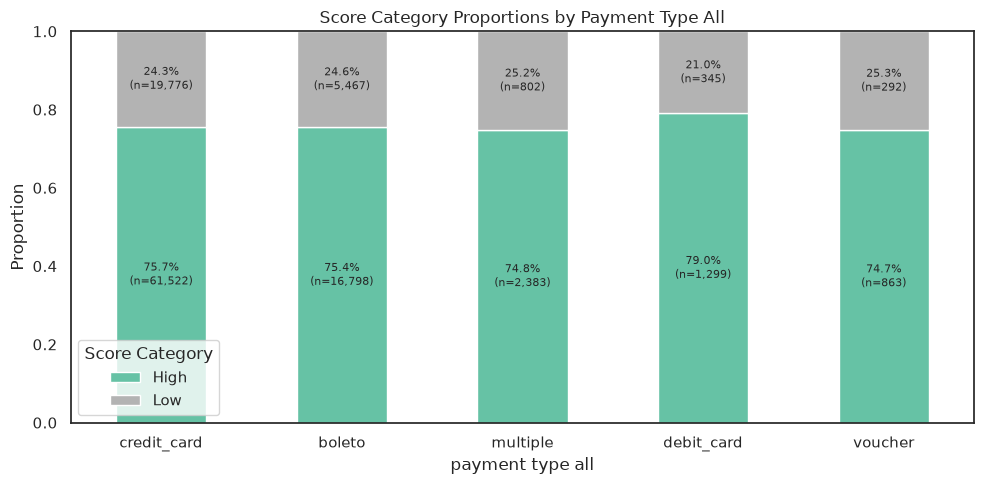

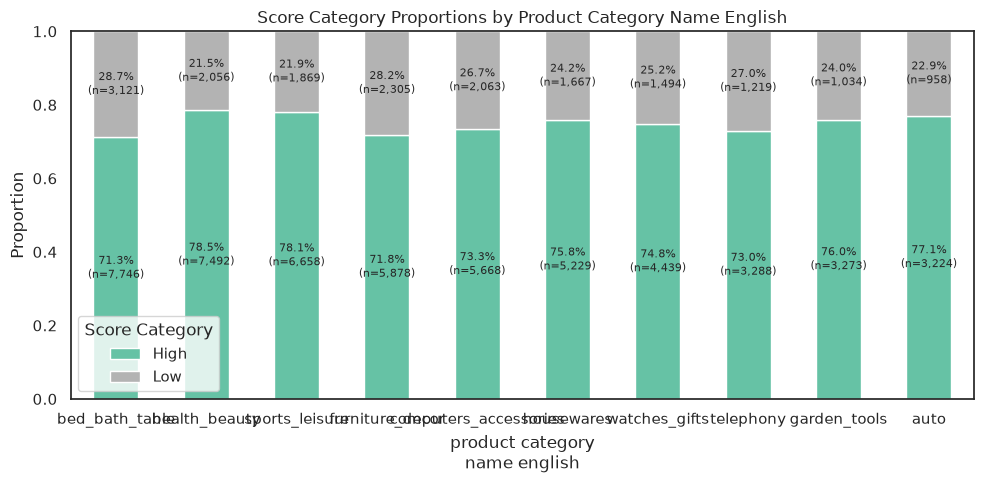

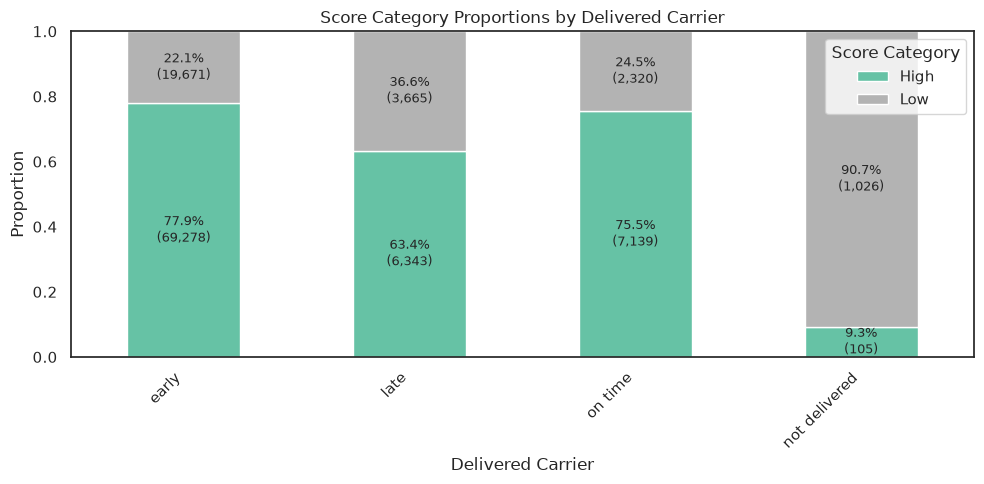

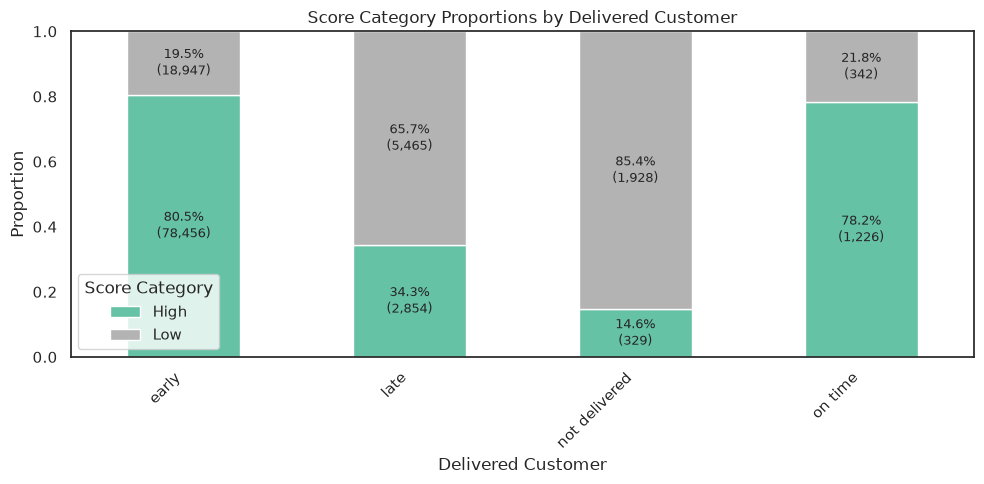

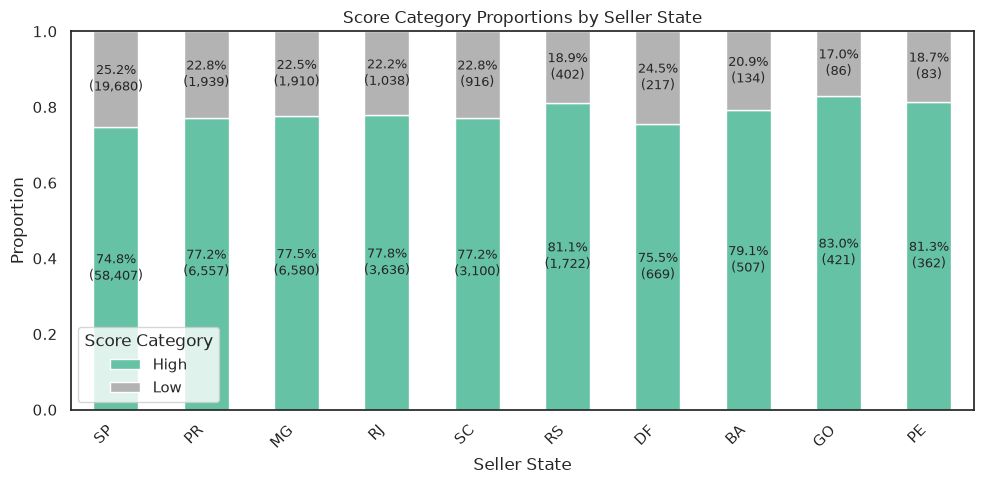

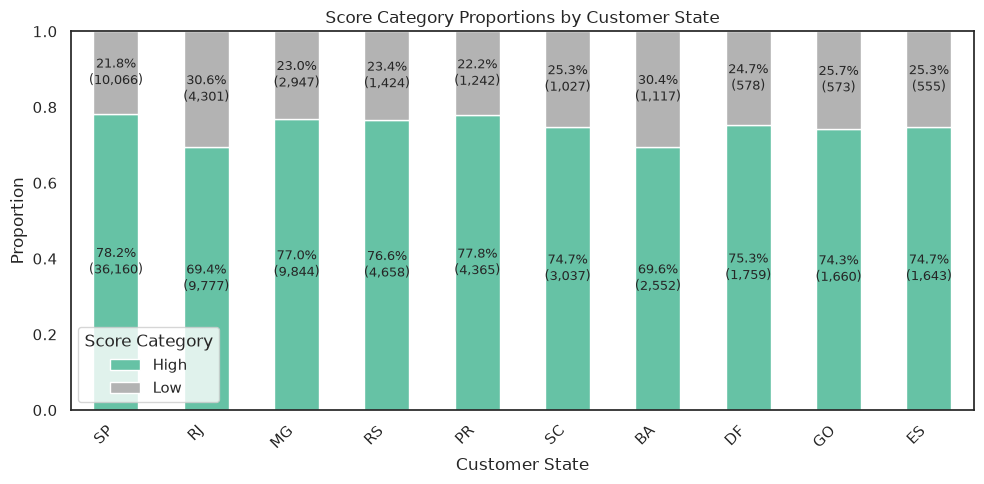

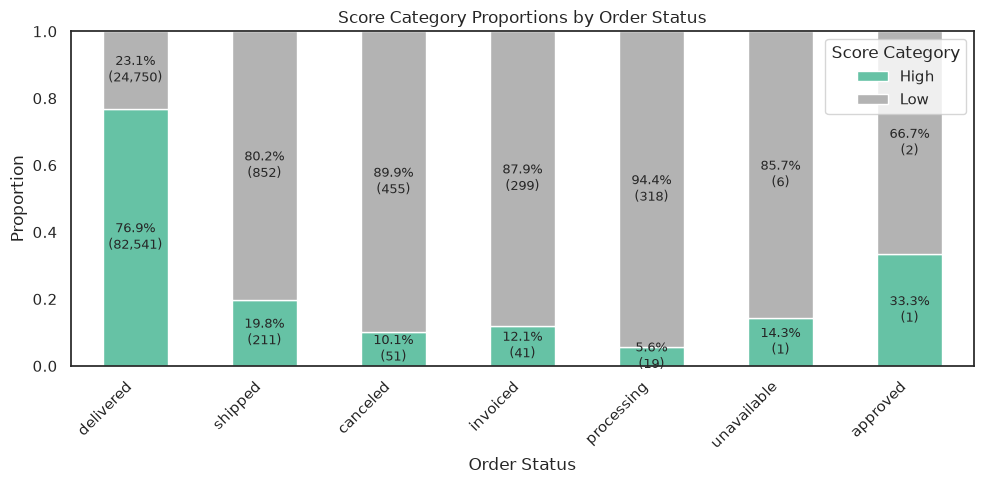

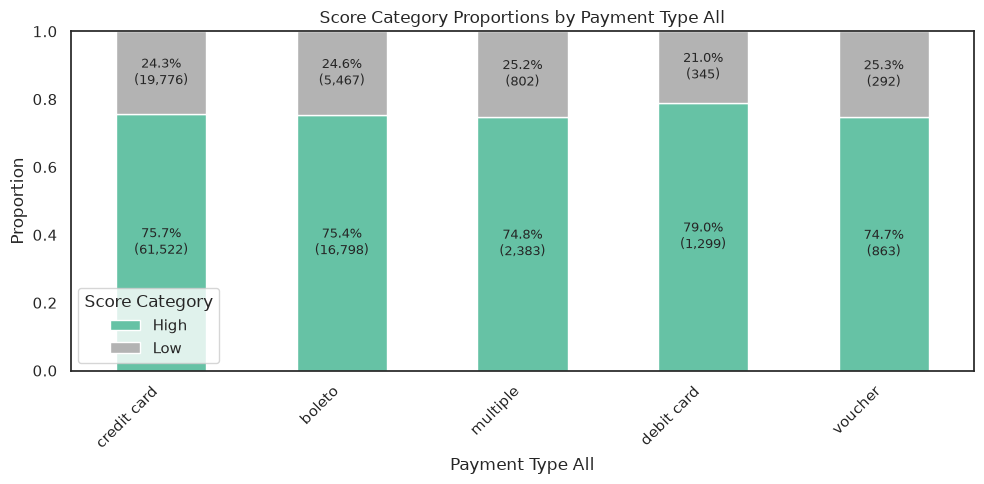

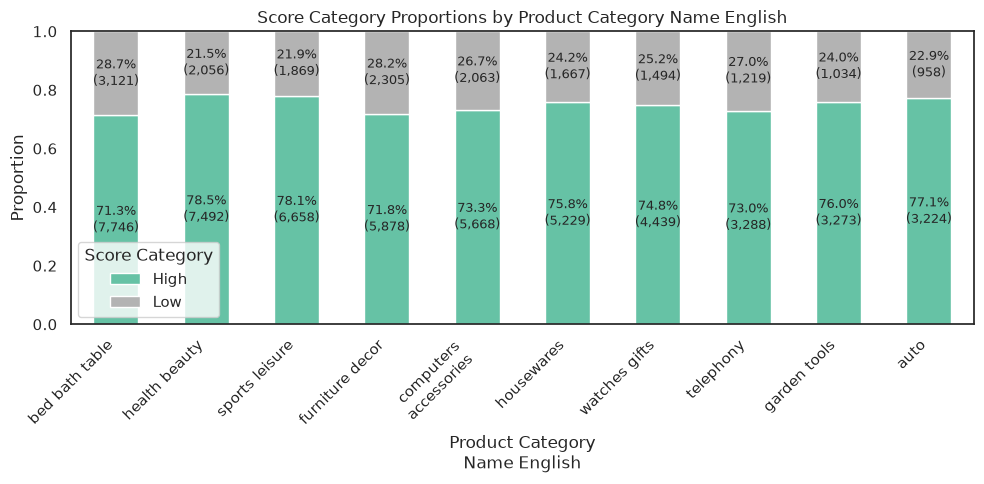

In [ ]:
categorical_cols = [
    "delivered_carrier",
    "delivered_customer",
    "seller_state",
    "customer_state",
    "order_status",
    "payment_type_all",
    "product_category_name_english",
]

for col in categorical_cols:
    column_label = format_labels([col])[0]
    top_categories = df[col].value_counts().head(10).index

    proportions = pd.crosstab(
        df[col],
        df["score_category"],
        normalize="index"
    ).loc[top_categories]
    tick_labels = format_labels(proportions.index.tolist())

    counts = pd.crosstab(
        df[col],
        df["score_category"]
    ).reindex(
        index=proportions.index,
        columns=proportions.columns,
        fill_value=0
    )

    ax = proportions.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5),
        colormap="Set2"
    )

    # Annotate each stacked segment
    for container, category in zip(ax.containers, proportions.columns):
        for patch, percentage, count in zip(
            container,
            proportions[category],
            counts[category]
        ):
            if percentage > 0.03:  # hide labels for very small segments
                ax.text(
                    patch.get_x() + patch.get_width() / 2,
                    patch.get_y() + patch.get_height() / 2,
                    f"{percentage:.1%}\n({count:,})",
                    ha="center",
                    va="center",
                    fontsize=9
                )

    ax.set_title(
        f"Score Category Proportions by {col.replace('_', ' ').title()}"
    )
   
    ax.legend(title="Score Category")
    ax.set_xlabel(column_label.title())
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(proportions.index)))
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Insights

* very high class imbalance for review scores
* customer_delivered_offset has the highest correlation score (albeit not very strong)
* correlation matrix does not show any strong indicator for the data to lean one way or another
* order_status might have some relation
* no pattern found for payment_type
* pattern found for reviews with titles/comments? (how to argue for this...)

# Feature Selection

In [ ]:
# Column removals come after EDA
# remove_cols = ['product_name_lenght','product_description_lenght','product_photos_qty','product_weight_g','product_length_cm','product_height_cm','seller_zip_code_prefix','customer_zip_code_prefix']
# df = df.drop(columns=remove_cols)
# print(f'Percentage of loss from removing columns: {len(remove_cols)} ({(len(df.columns)-len(df.columns))/len(df.columns):.2%})')

In [ ]:
COLUMNS AND ROWS LOST BETWEEN BEFORE CLEANING AND MERGING AND AFTER 

# Data Model (output)

In [ ]:
import os
# Save consolidated dataset

output_path = "./olist.csv"
df.to_csv(output_path, index=False)
print(f"✅ Saved consolidated dataset to: {output_path}")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Size: {os.path.getsize(output_path) / 1e6:.2f} MB")